In [60]:
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from os.path import join
import seaborn as sns

In [61]:
car = pd.read_csv('car_price_dataset_medium.csv')

print(f'Rows: {car.shape[0]}, Columns: {car.shape[1]}')
car.head()

Rows: 1000, Columns: 12


,Car_ID,Brand,Model_Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Engine_CC,Max_Power_bhp,Mileage_kmpl,Seats,Price_USD
0,1,Audi,2005,197018,Diesel,Manual,First,4046,223.6,29.61,6,119611.94
1,2,BMW,2019,43467,Hybrid,Automatic,First,3731,248.4,21.66,5,90842.46
2,3,Kia,2012,153697,Hybrid,Automatic,Third,4925,465.5,12.14,6,78432.24
3,4,Mercedes,2015,38893,Petrol,Automatic,Second,3771,229.7,19.65,6,44568.89
4,5,Audi,2016,81329,Hybrid,Automatic,First,2817,573.2,7.74,5,8751.82


In [62]:
car.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Car_ID             1000 non-null   int64  
 1   Brand              1000 non-null   object 
 2   Model_Year         1000 non-null   int64  
 3   Kilometers_Driven  1000 non-null   int64  
 4   Fuel_Type          1000 non-null   object 
 5   Transmission       1000 non-null   object 
 6   Owner_Type         1000 non-null   object 
 7   Engine_CC          1000 non-null   int64  
 8   Max_Power_bhp      1000 non-null   float64
 9   Mileage_kmpl       1000 non-null   float64
 10  Seats              1000 non-null   int64  
 11  Price_USD          1000 non-null   float64
dtypes: float64(3), int64(5), object(4)
memory usage: 93.9+ KB


In [63]:
car.describe().T

,count,mean,std,min,25%,50%,75%,max
Car_ID,1000.0,500.50000,288.819436,1.00,250.7500,500.500,750.2500,1000.00
Model_Year,1000.0,2014.49100,5.710738,2005.00,2009.7500,2015.000,2019.0000,2024.00
Kilometers_Driven,1000.0,103397.07400,57417.612935,5155.00,52188.5000,102449.000,152696.5000,199812.00
Engine_CC,1000.0,2878.29900,1212.337697,801.00,1818.2500,2857.500,3959.5000,4996.00
Max_Power_bhp,1000.0,320.93990,160.384514,40.50,184.8250,314.650,455.3000,599.60
Mileage_kmpl,1000.0,17.34144,7.297990,5.04,10.9700,17.145,24.0350,29.99
Seats,1000.0,4.66500,1.802783,2.00,4.0000,5.000,6.0000,7.00
Price_USD,1000.0,59217.24942,33545.254183,3028.42,30030.8225,56806.745,87088.8975,119611.94


In [64]:
car.isna().mean().sort_values(ascending=False).head(10)


Car_ID               0.0
Brand                0.0
Model_Year           0.0
Kilometers_Driven    0.0
Fuel_Type            0.0
Transmission         0.0
Owner_Type           0.0
Engine_CC            0.0
Max_Power_bhp        0.0
Mileage_kmpl         0.0
dtype: float64

In [65]:
car['Decade'] = (car['Model_Year'] // 10) * 10
car.head()

,Car_ID,Brand,Model_Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Engine_CC,Max_Power_bhp,Mileage_kmpl,Seats,Price_USD,Decade
0,1,Audi,2005,197018,Diesel,Manual,First,4046,223.6,29.61,6,119611.94,2000
1,2,BMW,2019,43467,Hybrid,Automatic,First,3731,248.4,21.66,5,90842.46,2010
2,3,Kia,2012,153697,Hybrid,Automatic,Third,4925,465.5,12.14,6,78432.24,2010
3,4,Mercedes,2015,38893,Petrol,Automatic,Second,3771,229.7,19.65,6,44568.89,2010
4,5,Audi,2016,81329,Hybrid,Automatic,First,2817,573.2,7.74,5,8751.82,2010


Segmenting the Data


In [66]:
df['Vehicle_Age'] = 2024 - df['Model_Year']

japanese_brands = ['Lexus', 'Toyota', 'Honda', 'Nissan']

def categorize_brand(brand):
    if brand in japanese_brands:
        return 'Japanese Premium'
    else:
        return 'Control Group (Overall Market)'

df['Market_Segment'] = df['Brand'].apply(categorize_brand)

## Filtering for the 10-Year Depreciation Window

df_10_years = df[df['Vehicle_Age'] <=10]



First Visualization : Derpeciation by Age

<function matplotlib.pyplot.show(close=None, block=None)>

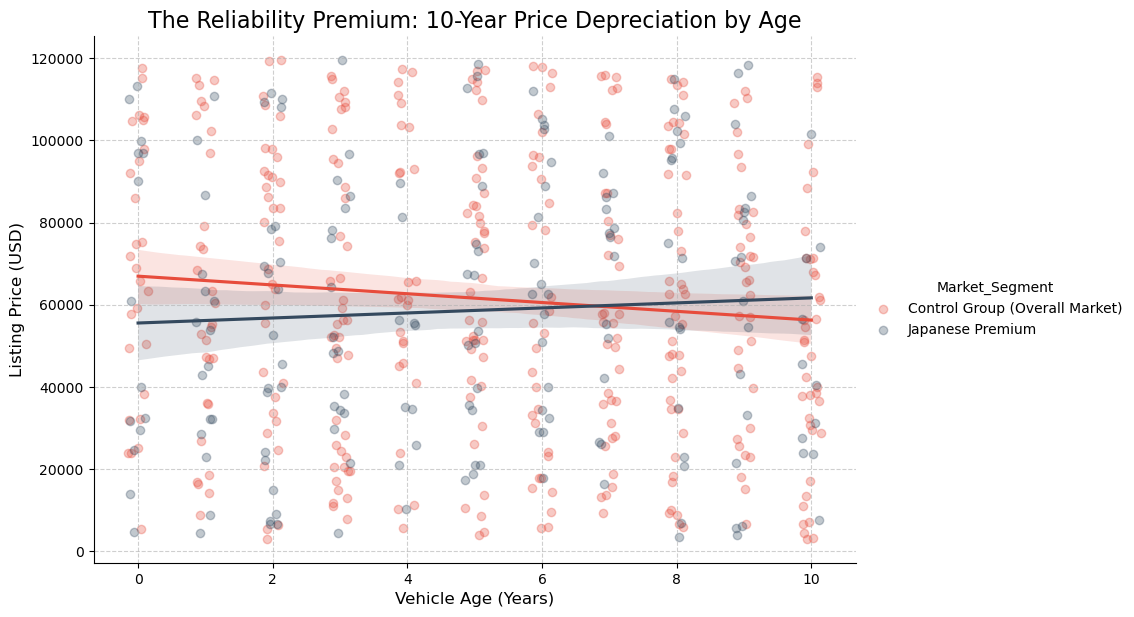

In [67]:
sns.lmplot(
    data=df_10_years,
    x='Vehicle_Age',
    y='Price_USD',
    hue='Market_Segment',
    scatter_kws={'alpha': 0.3},
    x_jitter=0.15, # Spreads the dots horizontally for better visibility
    aspect=1.5,
    height=6,
    palette=['#e74c3c', '#34495e']
)

# Fixed the quotation marks so fontsize acts as a parameter, not text
plt.title('The Reliability Premium: 10-Year Price Depreciation by Age', fontsize=16) 
plt.xlabel('Vehicle Age (Years)', fontsize=12)
plt.ylabel('Listing Price (USD)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show